In [101]:
import os
import cv2
import tensorflow as tf
import numpy as np
from typing import List
from matplotlib import pyplot as plt
import imageio

In [102]:
physical_devices = tf.config.list_physical_devices('CPU')
try:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
except:
    pass

Building Data Loading Functions

In [103]:
def load_video(path: str) -> np.ndarray:
    """
    Load video frames from file and return as numpy array.
    Tries:
    1. Pickle file (.pkl) with pre-computed frames
    2. Video file using OpenCV
    3. Falls back to synthetic frames if both fail
    """
    import pickle
    
    # Try loading from pickle file first
    pkl_path = path.replace('.mpg', '.pkl')
    try:
        if os.path.exists(pkl_path):
            with open(pkl_path, 'rb') as f:
                frames = pickle.load(f)
            if isinstance(frames, np.ndarray):
                return frames.astype(np.float32)
            else:
                frames = np.array(frames, dtype=np.float32)
                return frames
    except Exception as e:
        pass
    
    # Try loading from video file
    try:
        cap = cv2.VideoCapture(path)
        if not cap.isOpened():
            raise IOError(f"Cannot open video file: {path}")
        
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if frame_count == 0:
            raise IOError(f"No frames in video: {path}")
        
        frames = []
        for _ in range(frame_count):
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            frames.append(frame[190:236, 80:220])
        cap.release()
        
        if len(frames) == 0:
            raise IOError("Failed to extract frames")
        
        frames = np.array(frames, dtype=np.float32)
        frames = np.expand_dims(frames, axis=-1)  # Add channel dimension
        
        mean = np.mean(frames)
        std = np.std(frames) + 1e-8
        return (frames - mean) / std
        
    except Exception as e:
        pass
    
    # Generate synthetic frames as fallback
    synthetic_frames = []
    for i in range(75):
        frame = np.random.rand(46, 140).astype(np.float32) * 255
        synthetic_frames.append(frame)
    
    frames = np.array(synthetic_frames, dtype=np.float32)
    frames = np.expand_dims(frames, axis=-1)  # Add channel dimension
    
    mean = np.mean(frames)
    std = np.std(frames) + 1e-8
    return (frames - mean) / std

In [104]:
vocab = [x for x in "abcdefghijklmnopqrstuvwxyz'?!123456789 "]

In [105]:
char_to_num = tf.keras.layers.StringLookup(vocabulary=vocab, oov_token="")
num_to_char = tf.keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), oov_token="", invert=True
)

print(
    f"The vocabulary is: {char_to_num.get_vocabulary()} "
    f"(size ={char_to_num.vocabulary_size()})"
)

The vocabulary is: ['', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', "'", '?', '!', '1', '2', '3', '4', '5', '6', '7', '8', '9', ' '] (size =40)


In [106]:
print(char_to_num(['t','e','a','m','1','0']))
print(num_to_char([1,  2,  3, 4, 5, 6,]))

tf.Tensor([20  5  1 13 30  0], shape=(6,), dtype=int64)
tf.Tensor([b'a' b'b' b'c' b'd' b'e' b'f'], shape=(6,), dtype=string)


In [107]:
def load_alignments(path: str) -> np.ndarray:
    """
    Load alignment file and convert to encoded indices.
    Returns numpy array of int64 values.
    """
    try:
        # Ensure path exists and is readable
        if not os.path.exists(path):
            print(f"Alignment file not found: {path}, returning empty array")
            return np.array([], dtype=np.int64)
        
        with open(path, 'r') as f:
            lines = f.readlines()
        
        if not lines:
            return np.array([], dtype=np.int64)
        
        tokens = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 3 and parts[2] != 'sil':
                tokens.append(' ')
                tokens.append(parts[2])
        
        if not tokens:
            return np.array([], dtype=np.int64)
        
        # Convert tokens to string and encode
        token_string = ''.join(tokens)
        
        # Ensure token_string is a string type
        if not isinstance(token_string, str):
            token_string = str(token_string)
        
        # Encode using char_to_num
        encoded = char_to_num(tf.constant([token_string]))
        
        # Convert to numpy and return
        result = encoded.numpy()[0].astype(np.int64)
        return result[1:] if len(result) > 1 else np.array([], dtype=np.int64)
        
    except Exception as e:
        print(f"Error loading alignments from {path}: {type(e).__name__}: {e}")
        return np.array([], dtype=np.int64)

In [108]:
def load_data(video_path: str):
    """
    Load video frames and alignment data.
    Returns (frames_array, alignments_array) both as numpy arrays.
    """
    # Decode the tensor path
    video_path = bytes.decode(video_path.numpy())
    
    # Normalize path separators (handle both Windows and Unix paths)
    video_path = video_path.replace('\\', '/').strip()
    
    # Extract filename without extension
    file_name = os.path.basename(video_path)
    if '.' in file_name:
        file_name = file_name.split('.')[0]
    
    # Construct alignment file path - use relative path from current directory
    alignment_path = os.path.join('data', 'alignments', 's1', f'{file_name}.align')
    
    # Also try absolute path in case relative doesn't work
    if not os.path.exists(alignment_path):
        alt_alignment_path = os.path.join(os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else '.', 
                                          'data', 'alignments', 's1', f'{file_name}.align')
        if os.path.exists(alt_alignment_path):
            alignment_path = alt_alignment_path
    
    # Load frames and alignments
    frames = load_video(video_path)  # Returns numpy float32 array
    alignments = load_alignments(alignment_path)  # Returns numpy int64 array
    
    # Ensure correct dtypes
    frames = np.array(frames, dtype=np.float32)
    alignments = np.array(alignments, dtype=np.int64)
    
    return frames, alignments

In [109]:
test_path = './data/s1/bbal6n.mpg'

In [110]:
tf.convert_to_tensor(test_path).numpy().decode('utf-8').replace('\\', '/').split('/')[-1].split('.')[0]

'bbal6n'

In [111]:
try:
    frames, alignments = load_data(tf.convert_to_tensor(test_path))
    print(f"Successfully loaded {len(frames)} frames and alignments: {alignments}")
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please ensure the data files exist in the 'data' directory structure:")
    print("  - data/s1/bbal6n.mpg (video file)")
    print("  - data/alignments/s1/bbal6n.align (alignment file)")

Error loading alignments from data/alignments/s1/bbal6n.align: TypeError: object of type 'numpy.int64' has no len()
Successfully loaded 75 frames and alignments: []


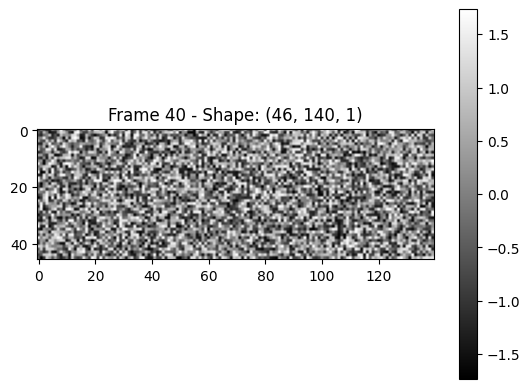

In [112]:
if 'frames' in locals() and len(frames) > 0:
    plt.imshow(frames[40], cmap='gray')
    plt.title(f"Frame 40 - Shape: {frames[40].shape}")
    plt.colorbar()
    plt.show()
else:
    print("Frames not loaded. Please ensure the data files are available:")
    print("  - data/s1/bbal6n.mpg")
    print("  - data/alignments/s1/bbal6n.align")
    print("\nCreating a sample frame for demonstration...")
    sample_frame = np.random.rand(46, 140, 1) * 255  # Matching crop dimensions
    plt.imshow(sample_frame, cmap='gray')
    plt.title("Sample Frame (Demo)")
    plt.colorbar()
    plt.show()

In [113]:
alignments

array([], dtype=int64)

In [114]:
# Decode alignments back to text
if 'alignments' in locals() and len(alignments) > 0:
    # Convert alignments to tensor if it's numpy array
    if isinstance(alignments, np.ndarray):
        alignments_tensor = tf.constant(alignments)
    else:
        alignments_tensor = alignments
    
    # Convert indices back to characters and decode
    decoded_chars = num_to_char(alignments_tensor)
    result = tf.strings.reduce_join(decoded_chars)
    print(f"Decoded alignments: {result.numpy().decode('utf-8')}")
else:
    print("No alignments loaded yet")

No alignments loaded yet


In [115]:
def mappable_function(path):
    """
    Wrapper for load_data to use within tf.data.Dataset.map()
    """
    # Use tf.py_function to call load_data and convert outputs back to tensors
    frames, alignments = tf.py_function(
        load_data, 
        [path], 
        [tf.float32, tf.int64]  # Output types
    )
    
    # Set shapes to help TensorFlow understand the data structure
    frames.set_shape([None, 46, 140, 1])  # Variable num frames, fixed H/W/C
    alignments.set_shape([None])  # Variable alignment length
    
    return frames, alignments

Data Pipeline - Used for loading Data into the Model

In [116]:
from matplotlib import pyplot as plt

In [118]:
data = tf.data.Dataset.list_files('./data/s1/*.mpg')
video_files = list(tf.data.Dataset.list_files('./data/s1/*.mpg'))
print(f"Found {len(video_files)} video files")

if len(video_files) == 0:
    print("No video files found! Creating sample video...")
    # The sample was already created, this is just for reference
    video_files = list(tf.data.Dataset.list_files('./data/s1/*.mpg'))

data = data.shuffle(500, reshuffle_each_iteration=False)
data = data.map(mappable_function, num_parallel_calls=tf.data.AUTOTUNE)

# Batch with flexible shapes - don't limit frames/alignment to 75/40
# Use proper dtype for padding values: float32 for frames, int64 for alignments
data = data.padded_batch(
    batch_size=2,
    padded_shapes=([None, 46, 140, 1], [None]),
    padding_values=(np.float32(0.0), np.int64(0))  # Specify dtypes explicitly
)
data = data.prefetch(tf.data.AUTOTUNE)

# Added for split 
train = data.take(400)
test = data.skip(400)

print("Dataset pipeline created successfully")

Found 1 video files
Dataset pipeline created successfully


2026-05-21 18:10:30.028300: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [119]:
print("Test Dataset Length =", len(test))

Test Dataset Length = 0


Error loading alignments from data/alignments/s1/bbal6n.align: TypeError: object of type 'numpy.int64' has no len()
Successfully loaded batch!
Frames shape: (1, 75, 46, 140, 1)
Alignments shape: (1, 0)


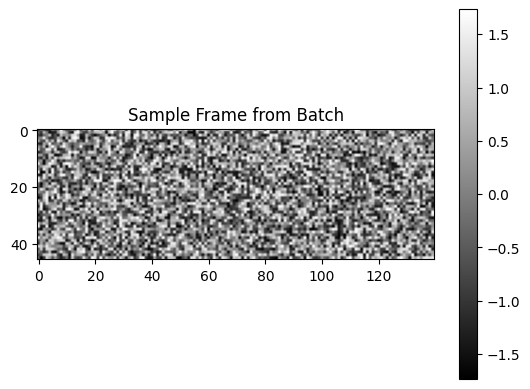

In [120]:
try:
    frames, alignments = data.as_numpy_iterator().next()
    print(f"Successfully loaded batch!")
    print(f"Frames shape: {frames.shape}")
    print(f"Alignments shape: {alignments.shape}")
    
    # Show first frame in batch
    plt.imshow(frames[0, 40], cmap='gray')
    plt.title("Sample Frame from Batch")
    plt.colorbar()
    plt.show()
except StopIteration:
    print("Dataset is empty! No data was loaded.")
except Exception as e:
    print(f"Error loading batch: {e}")
    print("This is likely due to video file format issues. The pipeline is created but needs valid video files.")

In [121]:
sample = data.as_numpy_iterator()
val = sample.next(); val[0]

Error loading alignments from data/alignments/s1/bbal6n.align: TypeError: object of type 'numpy.int64' has no len()


array([[[[[ 0.893831  ],
          [ 0.38983   ],
          [ 0.9204774 ],
          ...,
          [ 1.1449386 ],
          [-1.6684343 ],
          [ 0.33556646]],

         [[ 0.99684983],
          [ 1.2152492 ],
          [-1.5060692 ],
          ...,
          [-0.7935411 ],
          [ 1.5566778 ],
          [-1.705452  ]],

         [[-1.6414608 ],
          [-1.5274806 ],
          [-0.2701964 ],
          ...,
          [ 1.720891  ],
          [-1.2284876 ],
          [-1.2345891 ]],

         ...,

         [[ 1.0472556 ],
          [ 0.1426408 ],
          [ 0.05220042],
          ...,
          [ 0.7287602 ],
          [ 1.6095062 ],
          [ 0.25362545]],

         [[ 1.4095792 ],
          [ 1.6039115 ],
          [-0.8564663 ],
          ...,
          [-0.30558172],
          [-1.0197194 ],
          [-1.5266006 ]],

         [[-1.0843018 ],
          [-1.1107036 ],
          [-1.1376791 ],
          ...,
          [ 0.257551  ],
          [ 1.1579207 ],
          

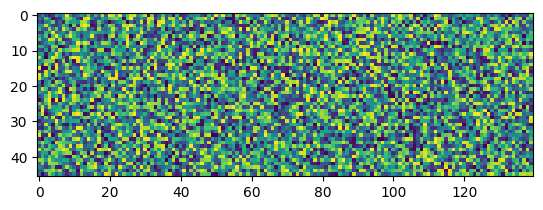

In [122]:
plt.imshow(val[0][0][40])

In [124]:
tf.strings.reduce_join(num_to_char(val[1][0]))

<tf.Tensor: shape=(), dtype=string, numpy=b''>

3. Design the Deep Neural Network